# Imports

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,f1_score,confusion_matrix
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import roc_auc_score, roc_curve


In [10]:
from bs4 import BeautifulSoup

In [14]:
import re
import nltk
import tqdm
import unicodedata
import contractions

from nltk.tokenize import word_tokenize

# These are the specific resources your code is looking for:
nltk.download('punkt')
nltk.download('punkt_tab')  # Required by newer NLTK versions
nltk.download('stopwords')   # You'll need this for your stopwords_removal function

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
import keras
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

from keras import initializers, regularizers, constraints, optimizers, layers
from keras.models import Model
from keras.layers import Input, Embedding, Bidirectional,LSTM,GRU ,Concatenate, Dense, Dropout, LSTM

In [16]:
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.regularizers import get as regularizer_get
from tensorflow.keras.constraints import get as constraint_get

# Exploratory Data Analysis

In [17]:
df = pd.read_csv('Suicide_Detection.csv')
df.head()

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [18]:
df.isna().sum().sum()

0

In [19]:
df.drop(columns = 'Unnamed: 0' , inplace = True)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 232074 entries, 0 to 232073
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    232074 non-null  str  
 1   class   232074 non-null  str  
dtypes: str(2)
memory usage: 3.5 MB


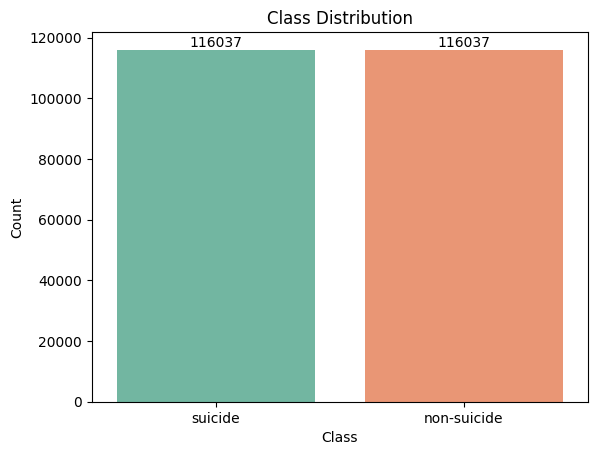

In [7]:
# sns.countplot(x= 'class', data=df, hue='class')
ax= sns.countplot(data=df, x="class", hue="class", legend=False, dodge=False, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [239]:
df['class'] = df['class'].replace({'suicide':1 , 'non-suicide':0})

In [240]:
df.shape[0]

232074

## Example texts from each class

In [73]:
Series_suicide = df[df['class']==1].sample(10)['text']

In [69]:
Series_suicide.iloc[2]

"I'm in the hospital now.3 days ago I attempted to kill myself. I went to my favourite place, down by the lake in the city I used to live in. I took a 12h overnight bus ride to kill myself. I bought a bottle of pills and took the whole thing. And then I waited. I walked around down by the lake, and if I wasn't waiting for the meds to kick it, it would have been quite a nice walk. Then I had to pee. Of course, because it's winter time all the washrooms by the lake are closed. So I walked up the road to a gas station and used the bathroom, then walked across the street to a coffee shop and used a payphone out front to call an ambulance. First time I had ever ridden in an ambulance. I was still coherent and perfectly lucid and remember everything. I had to drink charcoal, still as gross as I remember it. They pulled blood for testing every 2 hours the first night, then slightly less frequently. Poison control were the ones who ordered that. My arm is covered in bruises. And I have a 24h g

In [31]:
Series_suicide.iloc[4]

'Oh to have a time machineNot to prevent myself from making all the stupid mistakes I have, but to just stop my parents from having one last kid. They really couldn’t have stopped at 3? They had to make me, an ugly worthless unlovable piece of shit with no future? It’s not fair that I have to keep existing. I just want to be loved by anyone.'

In [34]:
Series_suicide.iloc[7]

'MehI have lived a good life. Learned a lot, (still learning everyday). I have loved and was loved by some amazing people. But I wasn’t built for this existence. Wasn’t assembled correctly. I’m tired. I’m ready for some rest.'

In [74]:
Series_suicide.iloc[9]

'My continued existence is a favour for other people while I perpetually suffer from it.There is nothing for me here, that outweighs the suffering.'

In [206]:
Series_non_suicide = df[df['class']==0].sample(10)['text']

In [207]:
Series_non_suicide.iloc[0]

"When CallMeCarson doesn't get convicted &amp;#x200B;\n\n*Processing img 6t6u4lazcsa61...*"

In [208]:
Series_non_suicide.iloc[1]

'First home Im nearly 19 and moving into my own home soon , it’s my first time living my self and I don’t have a job due to the pandemic. Wasn’t long ago I realised holy fuck there’s so much you need to buy - kettle, toaster, microwave, fridge, freezer, iron, hoover and so on and on and on. It’s a real eye opener and that’s just the ESSENTIALS off the top of my head there’s hundreds you need to buy but tbh I just want a couch, coffee table and tv in my living room and a bed in my bedroom easy as that but it’s all the stuff you need everyday the essentials. There’s also paint, gloss, carpet and laminate. Has anyone got any advice like life hacks or what’s necessary day to day'

In [209]:
Series_non_suicide.iloc[6]

'I’m such an idiot. I hate my life I forgot to take a screenshot when my snap score reached 69,420 and I checked and now it’s 69,495 please kill me'

In [205]:
Series_non_suicide.iloc[9]

"I found out something about my dad that I don't know what to think about. My dad's passcode to his xbox account is 696969."

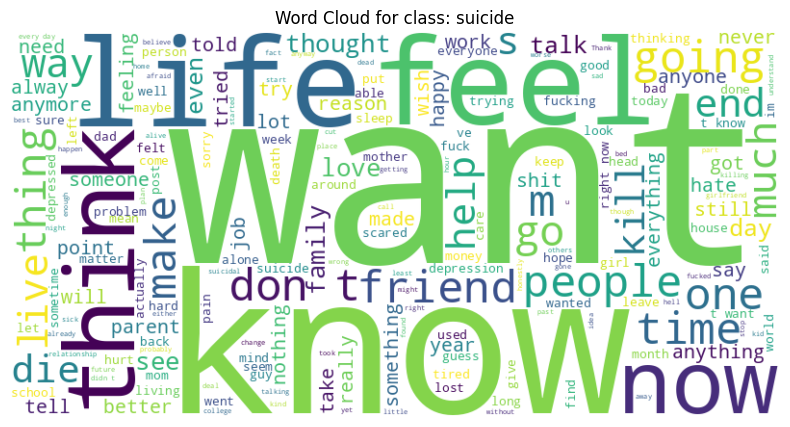

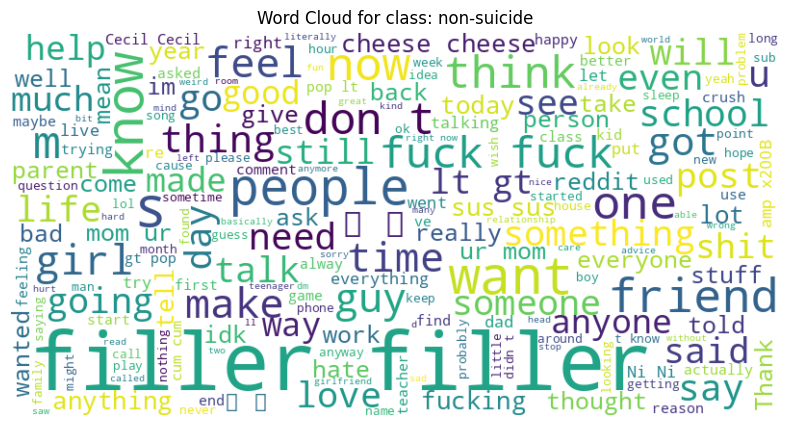

In [232]:
from wordcloud import WordCloud

for label in df["class"].unique():
    text_data = " ".join(df[df["class"] == label]["text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text_data)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for class: {label}")
    plt.show()

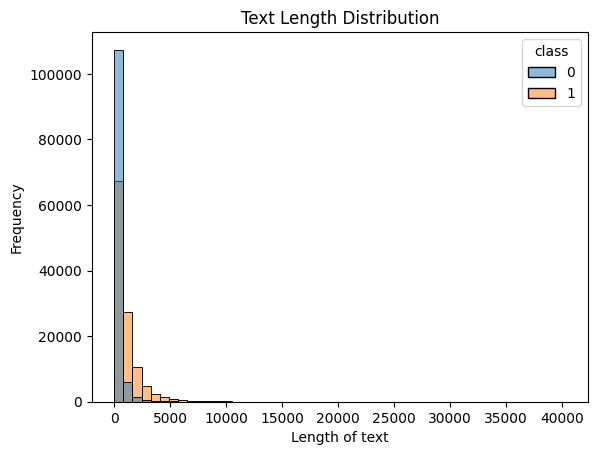

In [243]:
# Strip whitespace
df["text"] = df["text"].str.strip()
df["text_length"] = df["text"].str.len()
sns.histplot(data=df, x="text_length", bins=50, edgecolor="black", hue='class')
plt.title("Text Length Distribution")
plt.xlabel("Length of text")
plt.ylabel("Frequency")
plt.show()

In [ ]:
vocab_per_class = {
    label: len(set(" ".join(df[df["class"]==label]["text"]).split()))
    for label in df["class"].unique()
}

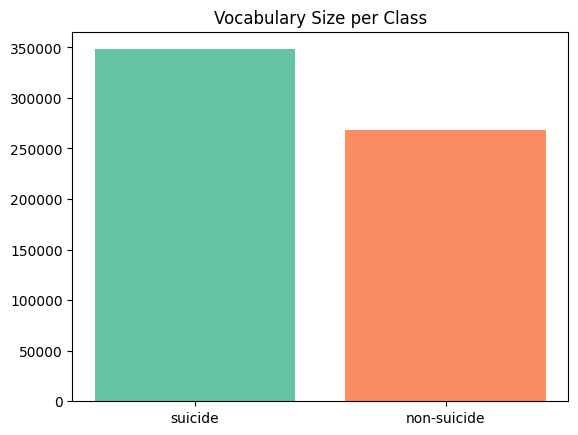

In [265]:
bar_colors = ['#66c2a5', '#fc8d62']
plt.bar(['suicide', 'non-suicide'], vocab_per_class.values(), color=bar_colors)
plt.title("Vocabulary Size per Class")
plt.show()

In [276]:
def evaluate(y_true, y_pred, title=""):
    print(title)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Set2")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()

# Cleaning the text

In [ ]:
def strip_html_tags(text):
  soup = BeautifulSoup(text, "html.parser")
  [s.extract() for s in soup(['iframe', 'script'])]
  stripped_text = soup.get_text()
  stripped_text = re.sub(r'[\r|\n|\r\n]+', '\n', stripped_text)
  return stripped_text

def remove_accented_chars(text):
  text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
  return text

def stopwords_removal(words):
    list_stopwords = nltk.corpus.stopwords.words('english')
    return [word for word in words if word not in list_stopwords]

In [284]:
def pre_process_corpus(docs):
  norm_docs = []
  for doc in tqdm.tqdm(docs):
    #case folding
    doc = doc.lower()
    #remove special characters\whitespaces
    doc = strip_html_tags(doc)
    doc = doc.translate(doc.maketrans("\n\t\r", "   "))
    doc = remove_accented_chars(doc)
    doc = contractions.fix(doc)
    doc = re.sub(r'[^a-zA-Z0-9\s]', '', doc, re.I|re.A)
    doc = re.sub(' +', ' ', doc)
    doc = doc.strip()
    #tokenize
    doc = word_tokenize(doc)
    #filtering
    doc = stopwords_removal(doc)
    norm_docs.append(doc)
  
  norm_docs = [" ".join(word) for word in norm_docs]
  return norm_docs

In [285]:
%%time
df.text = pre_process_corpus(df.text)

  0%|                                                                                        | 0/232074 [00:00<?, ?it/s]/tmp/ipykernel_22878/2253355324.py:4: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")
100%|█████████████████████████████████████████████████████████████████████████| 232074/232074 [02:30<00:00, 1537.00it/s]


CPU times: user 2min 24s, sys: 7.35 s, total: 2min 31s
Wall time: 2min 31s


In [286]:
df.head()

,text,class
0,ex wife threatening suiciderecently left wife ...,suicide
1,weird get affected compliments coming someone ...,non-suicide
2,finally 2020 almost never hear 2020 bad year e...,non-suicide
3,need helpjust help crying hard,suicide
4,losthello name adam 16 struggling years afraid...,suicide


# LSTM Classifier

In [287]:
X_train, X_test, y_train, y_test = train_test_split(df.text, df['class'], test_size=0.1, random_state=42)
X_train.shape , X_test.shape, y_train.shape, y_test.shape

((208866,), (23208,), (208866,), (23208,))

In [288]:
import keras
import tensorflow as tf

t = tf.keras.preprocessing.text.Tokenizer(oov_token='<UNK>') # it reserves an index for this token
# fit the tokenizer on the documents
t.fit_on_texts(X_test)
t.word_index['<PAD>'] = 0

2026-03-31 10:06:34.903382: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 10:06:34.947277: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 10:06:34.947323: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 10:06:34.947347: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 10:06:34.955085: I tensorflow/core/platform/cpu_feature_g

In [289]:
train_sequences = t.texts_to_sequences(X_train)
test_sequences = t.texts_to_sequences(X_test)

In [290]:
VOCAB_SIZE = len(t.word_index)

print("Vocabulary size={}".format(len(t.word_index)))
print("Number of Documents={}".format(t.document_count))

Vocabulary size=50882
Number of Documents=23208


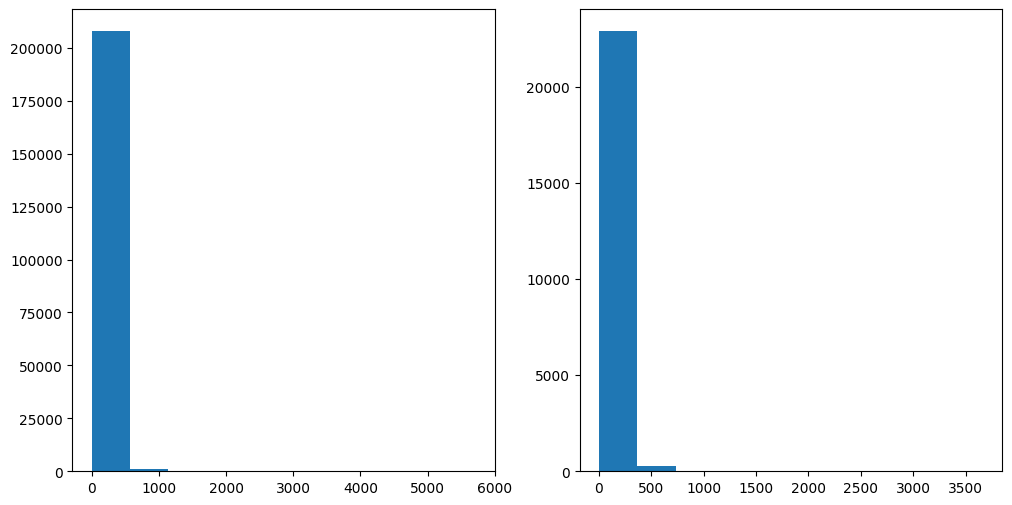

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

train_lens = [len(s) for s in train_sequences]
test_lens = [len(s) for s in test_sequences]

fig, ax = plt.subplots(1,2, figsize=(12, 6))
h1 = ax[0].hist(train_lens)
h2 = ax[1].hist(test_lens)

In [294]:
MAX_SEQUENCE_LENGTH = 150

from keras.preprocessing.sequence import pad_sequences
# pad dataset to a maximum review length in words
X_train = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH)
X_test = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH)
X_train.shape, X_test.shape

((208866, 150), (23208, 150))

In [295]:
le = LabelEncoder()
num_classes=2 

In [296]:
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [297]:
class AttentionLayer(Layer):
    
    def __init__(self, step_dim,
                 W_regularizer=None, b_regularizer=None,
                 W_constraint=None, b_constraint=None,
                 bias=True, **kwargs):
        
        self.supports_masking = True
        self.init = glorot_uniform()

        self.W_regularizer = regularizer_get(W_regularizer)
        self.b_regularizer = regularizer_get(b_regularizer)

        self.W_constraint = constraint_get(W_constraint)
        self.b_constraint = constraint_get(b_constraint)

        self.bias = bias
        self.step_dim = step_dim
        self.features_dim = 0
        super(AttentionLayer, self).__init__(**kwargs)
        

    def build(self, input_shape):
        assert len(input_shape) == 3

        self.W = self.add_weight(shape=(input_shape[-1],),
                                 initializer=self.init,
                                 name='{}_W'.format(self.name),
                                 regularizer=self.W_regularizer,
                                 constraint=self.W_constraint)
        self.features_dim = input_shape[-1]

        if self.bias:
            self.b = self.add_weight(shape=(input_shape[1],),
                                     initializer='zeros',
                                     name='{}_b'.format(self.name),
                                     regularizer=self.b_regularizer,
                                     constraint=self.b_constraint)
        else:
            self.b = None

        self.built = True
        

    def compute_mask(self, input, input_mask=None):
        return None

    
    def call(self, x, mask=None):
        features_dim = self.features_dim
        step_dim = self.step_dim

        eij = K.reshape(K.dot(K.reshape(x, (-1, features_dim)), 
                              K.reshape(self.W, (features_dim, 1))),
                        (-1, step_dim))

        if self.bias:
            eij += self.b

        eij = K.tanh(eij)

        a = K.exp(eij)

        if mask is not None:
            a *= K.cast(mask, K.floatx())

        a /= K.cast(K.sum(a, axis=1, keepdims=True) + K.epsilon(), K.floatx())
        a = K.expand_dims(a)
        weighted_input = x * a
        
        return K.sum(weighted_input, axis=1)

    
    def compute_output_shape(self, input_shape):
        return input_shape[0],  self.features_dim
    
    
    def get_config(self):
        config = {'step_dim': self.step_dim}
        base_config = super(AttentionLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


In [298]:
EMBEDDING_DIM = 200 # dimension for dense embeddings for each token
LSTM_DIM = 30 # total LSTM units

sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,))
embedded_sequences = Embedding(VOCAB_SIZE, EMBEDDING_DIM, trainable=True)(sequence_input)
bilstm = Bidirectional(LSTM(LSTM_DIM, return_sequences=True))(embedded_sequences)
#bigru = keras.layers.Bidirectional(keras.layers.GRU(GRU_DIM, return_sequences=True, recurrent_dropout=0.2))(embedded_sequences)
att = AttentionLayer(MAX_SEQUENCE_LENGTH)(bilstm)
dense1 = Dense(LSTM_DIM*2, activation='relu')(att)
dropout1 = Dropout(rate=0.315)(dense1)

outp = keras.layers.Dense(1, activation='sigmoid')(dropout1)
# outp = keras.layers.Dense(1, activation='sigmoid')(dense1)

# initialize the model
model = keras.models.Model(inputs=sequence_input, outputs=outp)

    
model.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(learning_rate=0.00001), metrics=['accuracy'])

2026-03-31 10:24:18.623893: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 10:24:18.634787: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 10:24:18.634843: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 10:24:18.637196: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 10:24:18.637282: I tensorflow/compile

In [299]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150)]             0         
                                                                 
 embedding (Embedding)       (None, 150, 200)          10176400  
                                                                 
 bidirectional (Bidirection  (None, 150, 60)           55440     
 al)                                                             
                                                                 
 attention_layer (Attention  (None, 60)                210       
 Layer)                                                          
                                                                 
 dense (Dense)               (None, 60)                3660      
                                                                 
 dropout (Dropout)           (None, 60)                0     

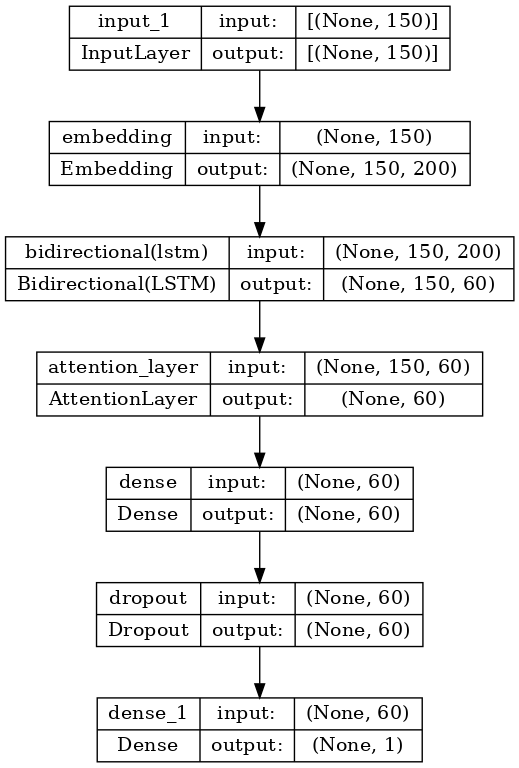

In [300]:
keras.utils.plot_model(model, show_shapes=True, dpi = 100)

In [301]:

epochs = 100
batch_size = 128

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
mc = ModelCheckpoint('./best_model_310326/best_model_gru.h5', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
history = model.fit(X_train, y_train,  batch_size=batch_size, shuffle=True, validation_split=0.1, epochs=epochs, verbose=1, callbacks=[es, mc])

Epoch 1/100


2026-03-31 10:25:55.621741: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2026-03-31 10:25:56.768866: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x77b2a42f07d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-31 10:25:56.768946: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A2000 Laptop GPU, Compute Capability 8.6
2026-03-31 10:25:56.773964: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-31 10:25:56.840956: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1469/1469 [==============================] - ETA: 0s - loss: 0.6532 - accuracy: 0.6376
Epoch 1: val_accuracy improved from -inf to 0.74051, saving model to ./best_model_310326/best_model_gru.h5


/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1469/1469 [==============================] - 101s 65ms/step - loss: 0.6532 - accuracy: 0.6376 - val_loss: 0.5644 - val_accuracy: 0.7405
Epoch 2/100
1469/1469 [==============================] - ETA: 0s - loss: 0.4114 - accuracy: 0.8361
Epoch 2: val_accuracy improved from 0.74051 to 0.88677, saving model to ./best_model_310326/best_model_gru.h5
1469/1469 [==============================] - 56s 38ms/step - loss: 0.4114 - accuracy: 0.8361 - val_loss: 0.3132 - val_accuracy: 0.8868
Epoch 3/100
1469/1469 [==============================] - ETA: 0s - loss: 0.2752 - accuracy: 0.9017
Epoch 3: val_accuracy improved from 0.88677 to 0.91722, saving model to ./best_model_310326/best_model_gru.h5
1469/1469 [==============================] - 55s 38ms/step - loss: 0.2752 - accuracy: 0.9017 - val_loss: 0.2315 - val_accuracy: 0.9172
Epoch 4/100
1469/1469 [==============================] - ETA: 0s - loss: 0.2245 - accuracy: 0.9196
Epoch 4: val_accuracy improved from 0.91722 to 0.92493, saving model to ./bes

# Model Evaluation

In [302]:
from keras.models import load_model

# Final evaluation of the model
# load the saved model
saved_model = load_model('./best_model_310326/best_model_gru.h5', custom_objects={'AttentionLayer': AttentionLayer})
train_acc = saved_model.evaluate(X_train, y_train, verbose=1)
test_acc = saved_model.evaluate(X_test, y_test, verbose=1)
print('Train: %.2f%%, Test: %.2f%%' % (train_acc[1]*100, test_acc[1]*100))

726/726 [==============================] - 10s 13ms/step - loss: 0.1999 - accuracy: 0.9382
Train: 96.82%, Test: 93.82%


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


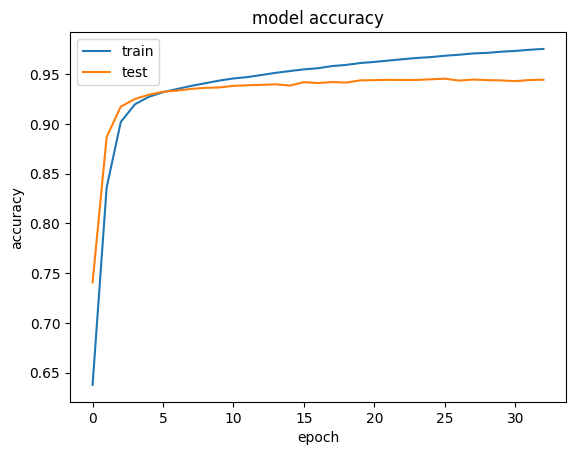

In [303]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.savefig('model accuracy dropout 0.5 balance.jpg')
plt.show()

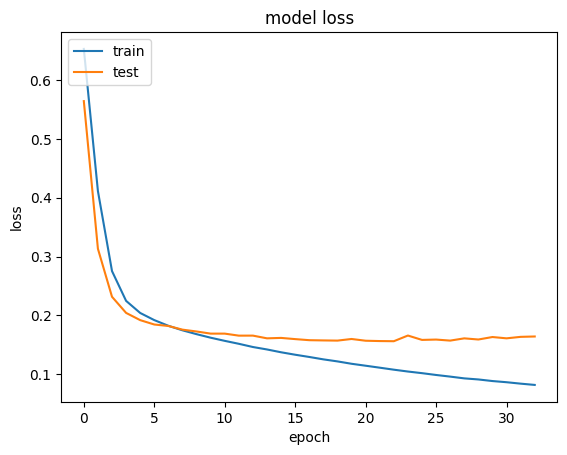

In [304]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.savefig('model loss dropout 0.5 balance.jpg')
plt.show()

In [305]:
prediction_probs = model.predict(X_test, verbose=1).ravel()
predictions = [1 if prob > 0.5 else 0 for prob in prediction_probs]

726/726 [==============================] - 7s 9ms/step


In [306]:
labels = ['positive', 'negative']
print(classification_report(y_test, predictions))
pd.DataFrame(confusion_matrix(y_test, predictions), index=labels, columns=labels)

              precision    recall  f1-score   support

           0       0.93      0.95      0.94     11699
           1       0.95      0.92      0.94     11509

    accuracy                           0.94     23208
   macro avg       0.94      0.94      0.94     23208
weighted avg       0.94      0.94      0.94     23208



,positive,negative
positive,11134,565
negative,889,10620


Bidirectional-LSTM
Accuracy: 0.9373491899345053
Macro F1: 0.9373184437961869
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     11699
           1       0.95      0.92      0.94     11509

    accuracy                           0.94     23208
   macro avg       0.94      0.94      0.94     23208
weighted avg       0.94      0.94      0.94     23208



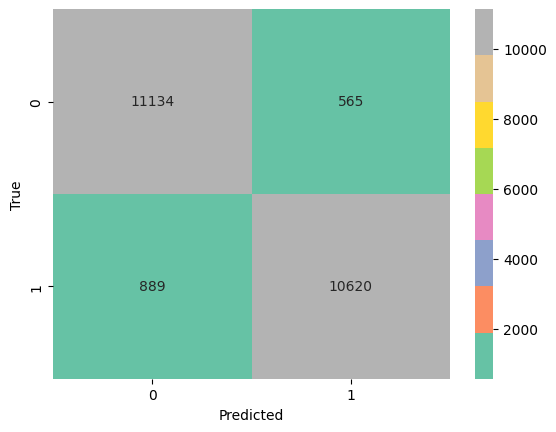

In [307]:
evaluate(y_test, predictions, title="Bidirectional-LSTM")

In [308]:
def plot_roc_curve(y_test, y_pred):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], ls="--")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

model AUC score: 0.9809995768761443


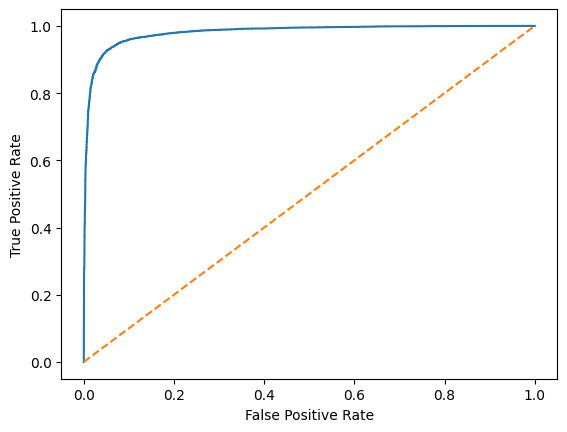

In [309]:
plot_roc_curve(y_test, prediction_probs)
print(f'model AUC score: {roc_auc_score(y_test, prediction_probs)}')

model f1 score: 0.9359302018154578 model AUC score: 0.9811663758332703


Text(0, 0.5, 'Precision')

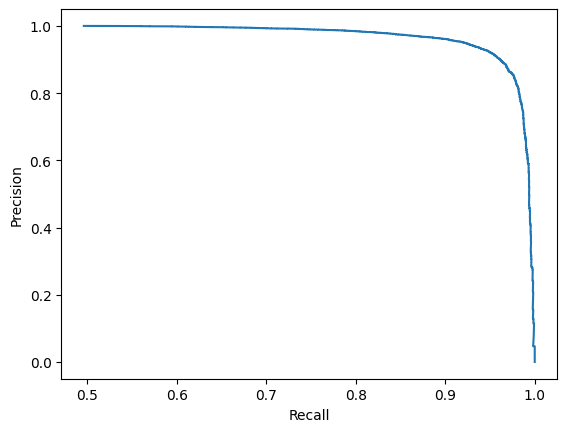

In [310]:
precision, recall, thresholds = precision_recall_curve(y_test, prediction_probs)
print(f'model f1 score: {f1_score(y_test, predictions)} model AUC score: {auc(recall, precision)}')
plt.plot(precision, recall)
plt.xlabel('Recall')
plt.ylabel('Precision')

In [311]:
# !pip freeze > requirements2.txt